# When Do Flights Leave Late? Seattle & Portland Departures, 2014

**Team:** [Member 1] · [Member 2] · [Member 3] · [Member 4]

## Business question
Operations at Seattle (SEA) and Portland (PDX) must decide where to put spare crews, gates and schedule buffer. **Which departures are most likely to leave more than 15 minutes late, and how much does weather matter compared with the schedule?**

## Summary
- **One flight in seven (14.4%)** left more than 15 minutes late.
- **Time of day matters most:** afternoon departures are delayed 21% of the time, early-morning ones 7%.
- **Carrier matters:** Southwest is delayed 27% of the time, Alaska 10%.
- **Weather matters only at the extremes**, such as freezing temperatures or poor visibility.
- **Our model ranks flights by risk well but cannot predict exact delay minutes.**

## 0. Setup

In [1]:
# ===== 1st code block (of 56) =====
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from scipy import stats

## 1. The data
- **`Flight.csv`:** every 2014 departure from SEA and PDX (162,049 flights).
- **`weather.csv`:** hourly weather at each airport (17,426 hours). An extra row of column numbers above its header is skipped when loading.

In [2]:
# ===== 2nd code block (of 56) =====
# Upload Flight.csv and weather.csv to Colab first (folder icon on the left)

df_flights = pd.read_csv('Flight.csv')

# weather.csv has an extra row of column numbers (1, 2, 3 ... 16) above the real header
# header=1 tells pandas the real column names are on the second row
df_weather = pd.read_csv('weather.csv', header=1)

print('Flights:', df_flights.shape)
print('Weather:', df_weather.shape)

# Check the files uploaded completely (large files can be cut off if the upload is interrupted)
if len(df_flights) != 162049 or len(df_weather) != 17426:
    print('WARNING: a file did not load completely - delete it in Colab, upload it again, wait for the upload to finish, then rerun')

Flights: (162049, 17)
Weather: (17426, 16)


In [3]:
# ===== 3rd code block (of 56) =====
df_flights.head()

,Key_Flight,year,month,day,dep_time,dep_delay,arr_time,arr_delay,carrier,tailnum,flight,origin,dest,air_time,distance,hour,minute
0,PDX-2014-1-1-0,2014,1,1,1.0,96.0,235.0,70.0,AS,N508AS,145,PDX,ANC,194.0,1542,0.0,1.0
1,SEA-2014-1-1-0,2014,1,1,4.0,-6.0,738.0,-23.0,US,N195UW,1830,SEA,CLT,252.0,2279,0.0,4.0
2,PDX-2014-1-1-0,2014,1,1,8.0,13.0,548.0,-4.0,UA,N37422,1609,PDX,IAH,201.0,1825,0.0,8.0
3,PDX-2014-1-1-0,2014,1,1,28.0,-2.0,800.0,-23.0,US,N547UW,466,PDX,CLT,251.0,2282,0.0,28.0
4,SEA-2014-1-1-0,2014,1,1,34.0,44.0,325.0,43.0,AS,N762AS,121,SEA,ANC,201.0,1448,0.0,34.0


In [4]:
# ===== 4th code block (of 56) =====
df_weather.head()

,Key_Weather,origin,year,month,day,hour,temp,dewp,humid,wind_dir,wind_speed,wind_gust,precip,pressure,visib,date
0,PDX-2014-1-1-0,PDX,2014,1,1,0,44.96,41.00,85.90,290.0,3.45234,3.972884,0.0,1026.9,8.0,01-01-14 0:00
1,PDX-2014-1-1-1,PDX,2014,1,1,1,44.96,39.92,82.38,290.0,6.90468,7.945768,0.0,1027.3,9.0,01-01-14 1:00
2,PDX-2014-1-1-2,PDX,2014,1,1,2,44.06,39.92,85.25,330.0,5.75390,6.621473,0.0,1027.4,9.0,01-01-14 2:00
3,PDX-2014-1-1-3,PDX,2014,1,1,3,44.06,39.92,85.25,280.0,6.90468,7.945768,0.0,1027.6,9.0,01-01-14 3:00
4,PDX-2014-1-1-4,PDX,2014,1,1,4,42.98,41.00,92.65,290.0,5.75390,6.621473,0.0,NaN,7.0,01-01-14 4:00


In [5]:
# ===== 5th code block (of 56) =====
# Missing values in the flight file before joining
print(df_flights.isnull().sum())

Key_Flight       0
year             0
month            0
day              0
dep_time       857
dep_delay      857
arr_time       988
arr_delay     1301
carrier          0
tailnum        248
flight           0
origin           0
dest             0
air_time      1301
distance         0
hour           857
minute         857
dtype: int64


In [6]:
# ===== 6th code block (of 56) =====
# 'date' in the weather file repeats year, month, day and hour, so we do not need it
df_weather = df_weather.drop(columns='date')

print('Flights:', df_flights.shape)
print('Weather:', df_weather.shape)

Flights: (162049, 17)
Weather: (17426, 15)


## 2. Combining the sources
Each flight is matched to the weather at its airport in the same hour, using the key we built in Excel for our VLOOKUP (for example SEA-2014-1-1-0). We chose a **left join**: it keeps every flight even when no weather exists, because flights are what we are explaining.

In [7]:
# ===== 7th code block (of 56) =====
# Is each weather hour listed only once? If not, the join would duplicate flights
print('Duplicate weather keys:', df_weather['Key_Weather'].duplicated().sum())

# How many hours of weather does each airport have? A full year is 365 x 24 = 8,760
print(df_weather.groupby('origin').size())

Duplicate weather keys: 0
origin
PDX    8712
SEA    8714
dtype: int64


In [8]:
# ===== 8th code block (of 56) =====
# Left join: keep every flight, add weather where the key matches
# Key_Flight and Key_Weather = origin-year-month-day-hour, e.g. SEA-2014-1-1-0 (same key as our Excel VLOOKUP)
# We only bring across the weather measurements - origin, year, month, day and hour are already in the flight file

weather_cols = ['Key_Weather', 'temp', 'dewp', 'humid', 'wind_dir', 'wind_speed',
                'wind_gust', 'precip', 'pressure', 'visib']

df = pd.merge(df_flights,
              df_weather[weather_cols],
              left_on='Key_Flight',
              right_on='Key_Weather',
              how='left')

print('Flights before join:', len(df_flights))
print('Rows after join:    ', len(df))

Flights before join: 162049
Rows after join:     162049


In [9]:
# ===== 9th code block (of 56) =====
# What did the join cost us?
matched = df['Key_Weather'].notnull().sum()
not_matched = df['Key_Weather'].isnull().sum()

print('Matched:    ', matched, f'({matched / len(df):.1%})')
print('Not matched:', not_matched, f'({not_matched / len(df):.1%})')

# Weather hours that no flight used (e.g. overnight when there are no departures)
print('Weather hours with no flight:', len(df_weather) - df['Key_Weather'].nunique())

Matched:     160280 (98.9%)
Not matched: 1769 (1.1%)
Weather hours with no flight: 2980


**What the join cost:** 160,280 flights (98.9%) matched and **1,769 (1.1%) did not**.

### Do the unmatched flights have anything in common?

In [10]:
# ===== 10th code block (of 56) =====
# Do the unmatched flights have anything in common?
unmatched = df[df['Key_Weather'].isnull()]

# 1. Cancelled flights have no departure time, so their key ends in "-NA"
cancelled = unmatched['dep_time'].isnull().sum()

# 2. Flights that left at exactly midnight are recorded as hour 24 - weather uses 0-23
hour_24 = (unmatched['hour'] == 24).sum()

# 3. The rest: flights in an hour that is missing from the weather file
missing_weather = not_matched - cancelled - hour_24

print('Cancelled flights:           ', cancelled)
print('Hour recorded as 24:         ', hour_24)
print('Hour missing in weather file:', missing_weather)

Cancelled flights:            857
Hour recorded as 24:          19
Hour missing in weather file: 893


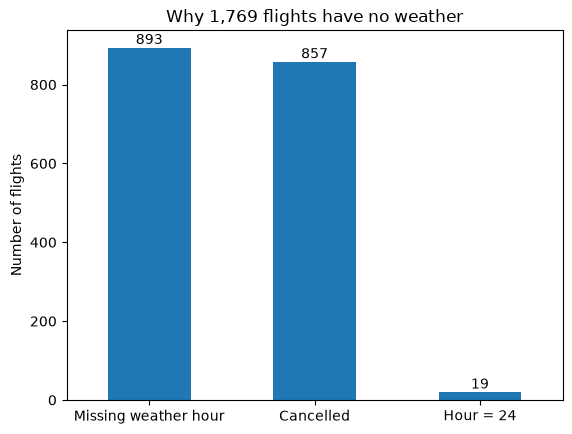

In [11]:
# ===== 11th code block (of 56) =====
# Bar chart of the three reasons, with the number of flights written on each bar
reasons = pd.Series({'Missing weather hour': missing_weather, 'Cancelled': cancelled, 'Hour = 24': hour_24})
reasons.plot(kind='bar')
for i, value in enumerate(reasons):
    plt.text(i, value + 10, value, ha='center')
plt.xticks(rotation=0)
plt.ylabel('Number of flights')
plt.title('Why 1,769 flights have no weather')
plt.show()

In [12]:
# ===== 12th code block (of 56) =====
# Which dates are missing weather?
missing = unmatched[unmatched['dep_time'].notnull() & (unmatched['hour'] != 24)]
missing_dates = missing.groupby(['month', 'day']).size().sort_values(ascending=False)
print(missing_dates.head(10))

# The weather file stops on 30 December
print('Last weather day:', df_weather[df_weather['month'] == 12]['day'].max())

month  day
12     31     389
7      20     139
       8      122
       9       70
2      19      46
6      9       41
       18      31
7      18      16
4      24      12
9      13      12
dtype: int64
Last weather day: 30


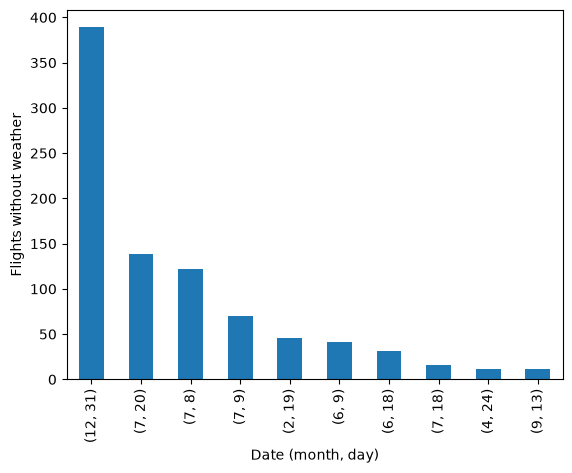

In [13]:
# ===== 13th code block (of 56) =====
missing_dates.head(10).plot(kind='bar')
plt.ylabel('Flights without weather')
plt.xlabel('Date (month, day)')
plt.show()

Yes, three groups:
- **857 cancelled flights**, which have no departure hour to match.
- **893 flights in hours missing from the weather file.** The file stops on 30 December, so all 389 New Year's Eve flights lack weather.
- **19 flights recorded at "hour 24"** (midnight).

The gaps sit on specific dates, not particular carriers or weather, so dropping them does not bias the findings. Python gives the same count as our Excel VLOOKUP.

In [14]:
# ===== 14th code block (of 56) =====
# Does the Python join agree with the Excel VLOOKUP?
# Optional: only runs if the Excel file is also uploaded to Colab
import os
if os.path.exists('Flight_and_Weather_-_working.xlsx'):
    df_excel = pd.read_excel('Flight_and_Weather_-_working.xlsx')
    # the last column of the Excel sheet is the key returned by VLOOKUP (blank = no match)
    print('Excel VLOOKUP - flights without weather:', df_excel.iloc[:, -1].isnull().sum())
    print('Python join   - flights without weather:', not_matched)

## 3. What the data contains and its condition
The combined table covers 2 airports, 71 destinations, 11 carriers and all of 2014. It is mostly complete.

In [15]:
# ===== 15th code block (of 56) =====
print('Rows and columns:', df.shape)
print('Airports:     ', df['origin'].unique().tolist())
print('Carriers:     ', df['carrier'].nunique())
print('Destinations: ', df['dest'].nunique())
print('Year:         ', df['year'].unique().tolist())

Rows and columns: (162049, 27)
Airports:      ['PDX', 'SEA']
Carriers:      11


Destinations:  71
Year:          [2014]


In [16]:
# ===== 16th code block (of 56) =====
df.describe().round(1)

,year,month,day,dep_time,dep_delay,arr_time,arr_delay,flight,air_time,distance,...,minute,temp,dewp,humid,wind_dir,wind_speed,wind_gust,precip,pressure,visib
count,162049.0,162049.0,162049.0,161192.0,161192.0,161061.0,160748.0,162049.0,160748.0,162049.0,...,161192.0,160247.0,160253.0,160247.0,156222.0,160208.0,160208.0,160280.0,134648.0,160274.0
mean,2014.0,6.6,15.7,1278.3,6.1,1482.5,2.2,1357.4,152.6,1204.5,...,30.3,54.1,45.3,74.5,156.5,7.1,8.1,0.0,1017.8,9.2
std,0.0,3.3,8.8,522.6,29.1,524.0,31.2,1495.3,72.5,653.2,...,18.1,11.4,22.3,17.0,110.0,5.0,5.7,0.0,6.6,2.3
min,2014.0,1.0,1.0,1.0,-37.0,1.0,-67.0,2.0,18.0,93.0,...,0.0,19.9,-2.9,12.3,0.0,0.0,0.0,0.0,986.4,0.0
25%,2014.0,4.0,8.0,831.0,-5.0,1127.0,-12.0,408.0,103.0,689.0,...,14.0,46.0,39.9,64.8,50.0,3.5,4.0,0.0,1014.0,10.0
50%,2014.0,7.0,16.0,1217.0,-2.0,1517.0,-4.0,694.0,129.0,991.0,...,30.0,54.0,46.9,79.4,170.0,6.9,7.9,0.0,1018.0,10.0
75%,2014.0,9.0,23.0,1721.0,5.0,1918.0,7.0,1726.0,199.0,1660.0,...,47.0,61.0,53.1,87.1,220.0,9.2,10.6,0.0,1021.4,10.0
max,2014.0,12.0,31.0,2400.0,1553.0,2400.0,1539.0,6527.0,422.0,2724.0,...,59.0,98.1,3282.8,100.0,360.0,38.0,43.7,0.3,1045.4,10.0


In [17]:
# ===== 17th code block (of 56) =====
# Missing values in each column
df.isnull().sum()

Key_Flight         0
year               0
month              0
day                0
dep_time         857
dep_delay        857
arr_time         988
arr_delay       1301
carrier            0
tailnum          248
flight             0
origin             0
dest               0
air_time        1301
distance           0
hour             857
minute           857
Key_Weather     1769
temp            1802
dewp            1796
humid           1802
wind_dir        5827
wind_speed      1841
wind_gust       1841
precip          1769
pressure       27401
visib           1775
dtype: int64

### Things that look wrong

In [18]:
# ===== 18th code block (of 56) =====
# Problem 1: dew point of 3,282 F is impossible (the maximum ever recorded on Earth is about 95 F)
print(df['dewp'].describe())
print('Rows with dew point above 100:', (df['dewp'] > 100).sum())

count    160253.000000
mean         45.341853
std          22.304347
min          -2.920000
25%          39.920000
50%          46.940000
75%          53.060000
max        3282.800000
Name: dewp, dtype: float64
Rows with dew point above 100: 6


In [19]:
# ===== 19th code block (of 56) =====
# Problem 2: wind_gust is always exactly 1.15 x wind_speed, so it is not a real measurement
ratio = df_weather['wind_gust'] / df_weather['wind_speed']
print(ratio.describe())

count    1.514700e+04
mean     1.150780e+00
std      1.241382e-16
min      1.150780e+00
25%      1.150780e+00
50%      1.150780e+00
75%      1.150780e+00
max      1.150780e+00
dtype: float64


In [20]:
# ===== 20th code block (of 56) =====
# Problem 3: pressure is missing for many flights
print('Share of flights missing pressure:', round(df['pressure'].isnull().mean() * 100, 1), '%')

Share of flights missing pressure: 16.9 %


In [21]:
# ===== 21st code block (of 56) =====
# Problem 4: 'hour' is the hour the flight ACTUALLY left, not the hour it was scheduled
# Example: a flight scheduled at 19:00 that is 3 hours late shows hour = 22
# Look at flights that left between 1am and 4am - they are all very late
print('Average delay of flights that left at 1-4am:',
      round(df[df['hour'].isin([1, 2, 3, 4])]['dep_delay'].mean()), 'minutes')

Average delay of flights that left at 1-4am: 105 minutes


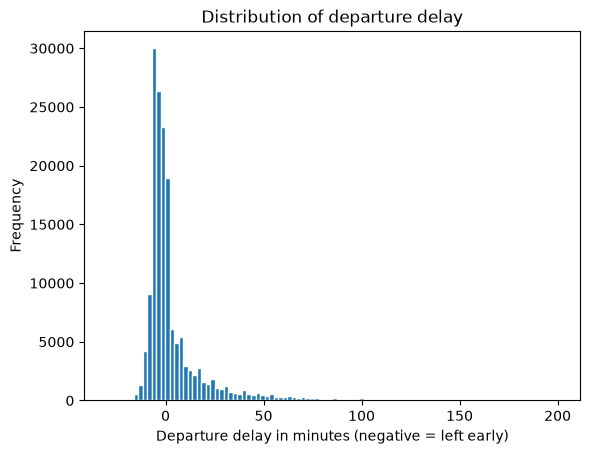

Mean:   6.1
Median: -2.0
Max:    1553.0


In [22]:
# ===== 22nd code block (of 56) =====
# Problem 5: the delay distribution is lopsided - a few very late flights pull the average up
df['dep_delay'].plot(kind='hist', bins=100, edgecolor='white', range=(-30, 200))
plt.title('Distribution of departure delay')
plt.xlabel('Departure delay in minutes (negative = left early)')
plt.show()

print('Mean:  ', round(df['dep_delay'].mean(), 1))
print('Median:', df['dep_delay'].median())
print('Max:   ', df['dep_delay'].max())

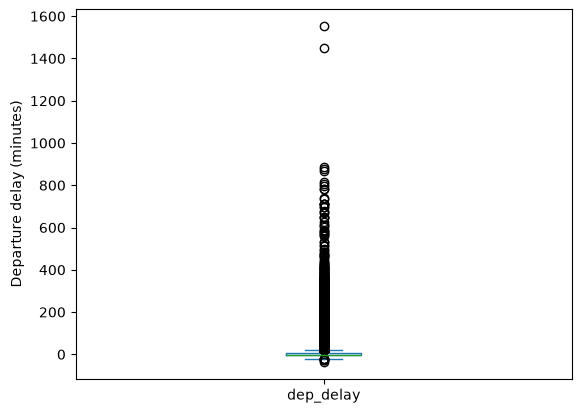

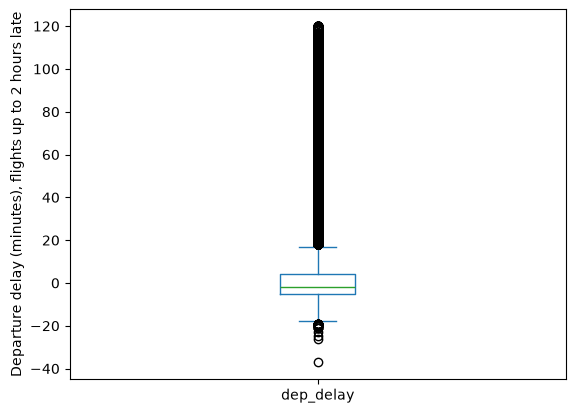

In [23]:
# ===== 23rd code block (of 56) =====
# Box plot (Session 5): the box holds the middle 50% of flights, the dots are outliers
df['dep_delay'].plot(kind='box')
plt.ylabel('Departure delay (minutes)')
plt.show()

# Same box plot without flights more than 2 hours late, so the box is visible
df[df['dep_delay'] <= 120]['dep_delay'].plot(kind='box')
plt.ylabel('Departure delay (minutes), flights up to 2 hours late')
plt.show()

We found five problems:
1. **An impossible dew point** (3,282°F) in 6 rows.
2. **Wind gust is not a real measurement**: it is always exactly 1.15 × wind speed.
3. **Air pressure is missing for 17% of flights.**
4. **"hour" is when the flight actually left, not when it was scheduled.** A 7pm flight delayed three hours shows as 10pm, so flights "leaving" at 1–4am averaged 105 minutes late.
5. **Delays are lopsided.** The box plot shows most flights within a few minutes of on time (median −2), but hundreds of outliers, up to 26 hours late, pull the average to 6 minutes.

### Cleaning decisions

In [24]:
# ===== 24th code block (of 56) =====
# Cleaning step 1: set the impossible dew point to missing
corr_before = df['dewp'].corr(df['dep_delay'])
df.loc[df['dewp'] > 100, 'dewp'] = np.nan
corr_after = df['dewp'].corr(df['dep_delay'])
print('Correlation of dew point with delay - before:', round(corr_before, 3), ' after:', round(corr_after, 3))

Correlation of dew point with delay - before: -0.014  after: -0.027


In [25]:
# ===== 25th code block (of 56) =====
# Cleaning step 2: drop wind_gust (copy of wind_speed) and pressure (17% missing)
df = df.drop(columns=['wind_gust', 'pressure'])

In [26]:
# ===== 26th code block (of 56) =====
# Cleaning step 3: rebuild the SCHEDULED departure hour
# dep_time is written as hhmm (e.g. 1930 = 19:30). Convert to minutes after midnight,
# subtract the delay, and convert back to an hour
dep_minutes = (df['dep_time'] // 100) * 60 + (df['dep_time'] % 100)
sched_minutes = (dep_minutes - df['dep_delay']) % (24 * 60)
df['sched_hour'] = sched_minutes // 60

# Check: flights that left at 1-4am were mostly scheduled in the evening
df[df['hour'].isin([1, 2, 3, 4])]['sched_hour'].value_counts().head()

sched_hour
23.0    99
0.0     65
22.0    21
1.0     14
19.0     4
Name: count, dtype: int64

In [27]:
# ===== 27th code block (of 56) =====
# Cleaning step 4: cancelled flights have no delay to measure - keep them out of the delay analysis
print('Cancelled flights:', df['dep_time'].isnull().sum())

# Cleaning step 5: flights without weather can't be used in the weather analysis
# Analysis set = flights that departed AND have weather
df_clean = df[df['dep_time'].notnull() & df['Key_Weather'].notnull()].copy()
print('Flights in analysis set:', len(df_clean))

Cancelled flights: 857


Flights in analysis set: 160280


In [28]:
# ===== 28th code block (of 56) =====
# Cleaning step 6: add a yes/no column: was the flight more than 15 minutes late?
# 15 minutes is the official airline industry definition of "delayed"
df_clean['delayed'] = (df_clean['dep_delay'] > 15).astype(int)

In [29]:
# ===== 29th code block (of 56) =====
# Cleaning step 7: keep extreme delays - they are real events, not errors
# How much would removing the worst 1% change the average?
cutoff = df_clean['dep_delay'].quantile(0.99)
print('99th percentile delay:', cutoff, 'minutes')
print('Average delay with all flights:     ', round(df_clean['dep_delay'].mean(), 2))
print('Average delay without the worst 1%: ', round(df_clean[df_clean['dep_delay'] <= cutoff]['dep_delay'].mean(), 2))

99th percentile delay: 127.0 minutes
Average delay with all flights:      6.13
Average delay without the worst 1%:  4.16


In [30]:
# ===== 30th code block (of 56) =====
# Cleaning log - every decision in one table
cleaning_log = [
    {'Step': 'Skipped first row of weather.csv', 'Why': 'Row of column numbers above the real header', 'Rows affected': 1},
    {'Step': 'Dropped weather date column', 'Why': 'Repeats year, month, day, hour', 'Rows affected': 'all'},
    {'Step': 'Dew point > 100 set to missing', 'Why': 'Physically impossible value (3,282 F)', 'Rows affected': 6},
    {'Step': 'Dropped wind_gust', 'Why': 'Always 1.15 x wind_speed, not a real measurement', 'Rows affected': 'all'},
    {'Step': 'Dropped pressure', 'Why': '17% missing', 'Rows affected': 'all'},
    {'Step': 'Added sched_hour', 'Why': 'hour is actual departure hour, which already contains the delay', 'Rows affected': 'all'},
    {'Step': 'Removed cancelled flights', 'Why': 'No delay to measure', 'Rows affected': 857},
    {'Step': 'Removed flights without weather', 'Why': 'Needed for weather analysis', 'Rows affected': 912},
    {'Step': 'Added delayed column (> 15 min)', 'Why': 'Industry definition of a delay', 'Rows affected': 'all'},
    {'Step': 'Kept extreme delays', 'Why': 'Real events that matter to passengers', 'Rows affected': 0},
]
pd.DataFrame(cleaning_log)

,Step,Why,Rows affected
0,Skipped first row of weather.csv,Row of column numbers above the real header,1
1,Dropped weather date column,"Repeats year, month, day, hour",all
2,Dew point > 100 set to missing,"Physically impossible value (3,282 F)",6
3,Dropped wind_gust,"Always 1.15 x wind_speed, not a real measurement",all
4,Dropped pressure,17% missing,all
5,Added sched_hour,"hour is actual departure hour, which already c...",all
6,Removed cancelled flights,No delay to measure,857
7,Removed flights without weather,Needed for weather analysis,912
8,Added delayed column (> 15 min),Industry definition of a delay,all
9,Kept extreme delays,Real events that matter to passengers,0


**What difference the cleaning made:**
- **Fixing the dew point** moved its correlation with delay from −0.014 to −0.027: six bad values distorted it.
- **Rebuilding the scheduled hour** showed the "1–4am flights" were late-evening flights that slipped past midnight.
- **Keeping extreme delays:** removing the worst 1% would cut the average from 6.1 to 4.2 minutes and flatter performance.

## 4. Baseline: the simplest possible answer

In [31]:
# ===== 31st code block (of 56) =====
# The simplest possible answer: "every flight is delayed by the average amount"
avg_delay = df_clean['dep_delay'].mean()
print('Average delay:', round(avg_delay, 1), 'minutes')

# How wrong is that guess on average? (mean absolute error)
baseline_error = (df_clean['dep_delay'] - avg_delay).abs().mean()
print('Baseline error (MAE):', round(baseline_error, 1), 'minutes')

Average delay: 6.1 minutes
Baseline error (MAE): 14.3 minutes


In [32]:
# ===== 32nd code block (of 56) =====
# For the yes/no question: "is this flight going to be delayed?"
pct_delayed = df_clean['delayed'].mean()
print('Share of flights delayed more than 15 minutes:', round(pct_delayed * 100, 1), '%')
print('Guessing "on time" for every flight is right', round((1 - pct_delayed) * 100, 1), '% of the time')
print('...but it never catches a single delay')

Share of flights delayed more than 15 minutes: 14.4 %
Guessing "on time" for every flight is right 85.6 % of the time
...but it never catches a single delay


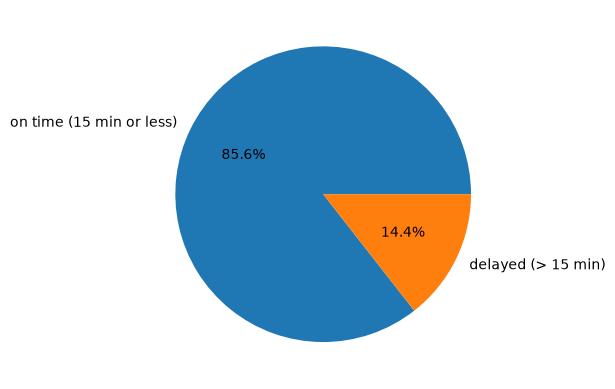

In [33]:
# ===== 33rd code block (of 56) =====
# Pie chart: on time vs delayed (Session 5: value_counts(normalize=True))
df_clean['delayed'].map({0: 'on time (15 min or less)', 1: 'delayed (> 15 min)'}).value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.ylabel('')
plt.show()

- **"Every flight is delayed by the average (6 minutes)"** is off by **14.3 minutes** on a typical flight.
- **"Every flight will be on time"** is right **85.6%** of the time but never catches a delay.

Any model must beat these.

## 5. What drives delay?
Bars show the share of flights delayed, with 95% confidence intervals; the red line is the average. Box plots show the spread of delay minutes.

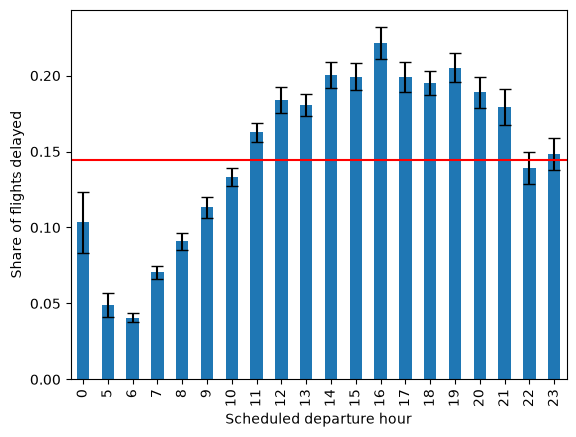

In [34]:
# ===== 34th code block (of 56) =====
# Chart 1: share of flights delayed, by scheduled hour
hour_stats = df_clean.groupby('sched_hour')['delayed'].agg(['mean', 'sem', 'size'])
hour_stats = hour_stats[hour_stats['size'] > 200]      # drop hours with very few flights
hour_stats.index = hour_stats.index.astype(int)          # show 5 instead of 5.0

hour_stats['mean'].plot(kind='bar', yerr=1.96 * hour_stats['sem'], capsize=4)
plt.axhline(pct_delayed, color='red')   # the average of all flights
plt.xlabel('Scheduled departure hour')
plt.ylabel('Share of flights delayed')
plt.show()

In [35]:
# ===== 35th code block (of 56) =====
# Group the hours into times of day
df_clean['time_of_day'] = pd.cut(df_clean['sched_hour'], bins=[-1, 4, 9, 13, 16, 20, 23],
                                 labels=['night 0-4', 'morning 5-9', 'midday 10-13', 'afternoon 14-16', 'evening 17-20', 'late 21-23'])

# Crosstab (Session 5): share of on-time and delayed flights in each time of day
pd.crosstab(df_clean['time_of_day'], df_clean['delayed'], normalize='index').round(3)

delayed,0,1
time_of_day,,
night 0-4,0.897,0.103
morning 5-9,0.928,0.072
midday 10-13,0.837,0.163
afternoon 14-16,0.794,0.206
evening 17-20,0.803,0.197
late 21-23,0.845,0.155


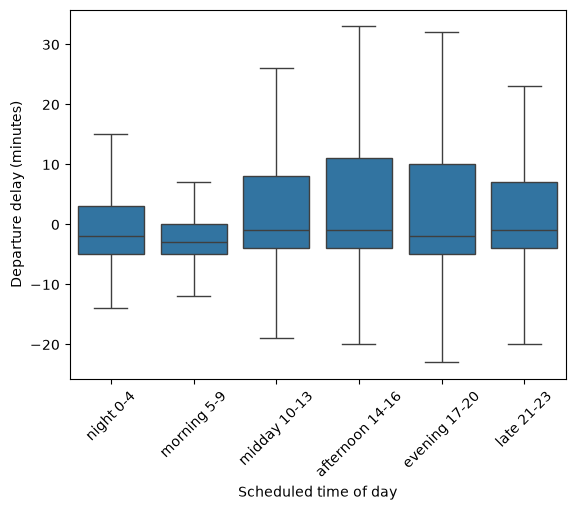

In [36]:
# ===== 36th code block (of 56) =====
# Chart 2: box plot of delay minutes by time of day (Session 5)
order = ['night 0-4', 'morning 5-9', 'midday 10-13', 'afternoon 14-16', 'evening 17-20', 'late 21-23']
sns.boxplot(x='time_of_day', y='dep_delay', data=df_clean, order=order, showfliers=False)   # showfliers=False hides outlier dots
plt.xticks(rotation=45)
plt.xlabel('Scheduled time of day')
plt.ylabel('Departure delay (minutes)')
plt.show()

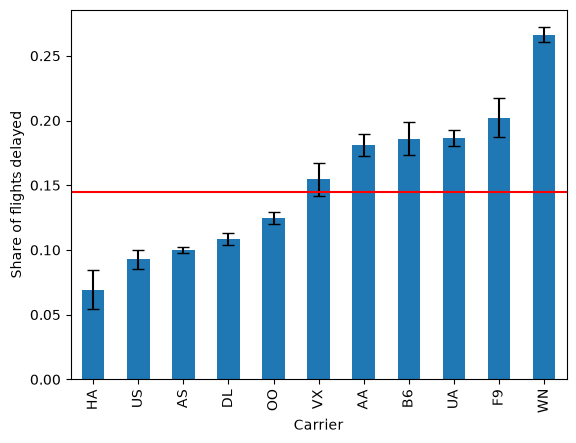

,mean,sem,size
carrier,,,
HA,0.069124,0.007705,1085
US,0.092678,0.003789,5859
AS,0.099710,0.001203,62010
DL,0.108645,0.002417,16577
OO,0.124475,0.002438,18341
VX,0.154462,0.006340,3250
AA,0.181088,0.004457,7466
B6,0.185953,0.006602,3474
UA,0.186415,0.003040,16415


In [37]:
# ===== 37th code block (of 56) =====
# Chart 3: share delayed by carrier
carrier_stats = df_clean.groupby('carrier')['delayed'].agg(['mean', 'sem', 'size']).sort_values('mean')

carrier_stats['mean'].plot(kind='bar', yerr=1.96 * carrier_stats['sem'], capsize=4)
plt.axhline(pct_delayed, color='red')
plt.xlabel('Carrier')
plt.ylabel('Share of flights delayed')
plt.show()

carrier_stats

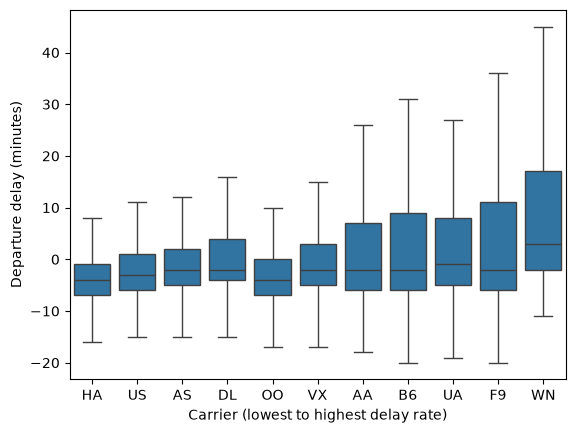

In [38]:
# ===== 38th code block (of 56) =====
# Chart 4: box plot of delay minutes by carrier
sns.boxplot(x='carrier', y='dep_delay', data=df_clean, order=carrier_stats.index, showfliers=False)
plt.xlabel('Carrier (lowest to highest delay rate)')
plt.ylabel('Departure delay (minutes)')
plt.show()

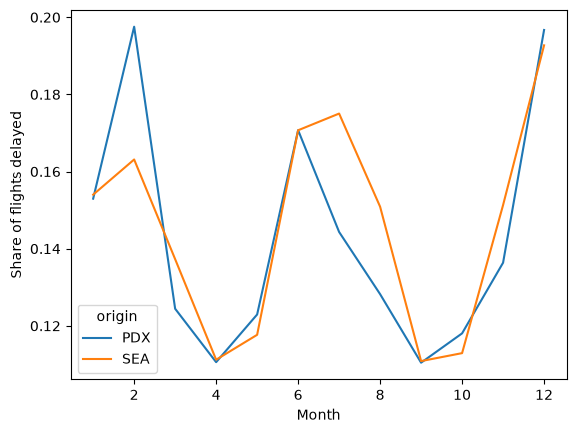

In [39]:
# ===== 39th code block (of 56) =====
# Chart 5: Seattle vs Portland, by month
df_clean.groupby(['month', 'origin'])['delayed'].mean().unstack().plot()
plt.xlabel('Month')
plt.ylabel('Share of flights delayed')
plt.show()

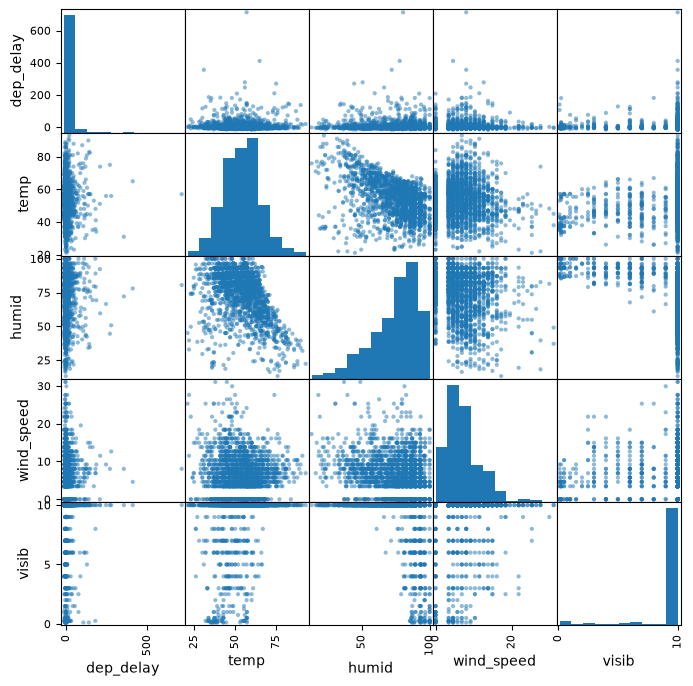

In [40]:
# ===== 40th code block (of 56) =====
# Chart 6: scatter matrix of weather measurements (Session 6)
# A random sample of 2,000 flights keeps the chart readable; the diagonal shows histograms
pd.plotting.scatter_matrix(df_clean[['dep_delay', 'temp', 'humid', 'wind_speed', 'visib']].sample(2000, random_state=1),
                           figsize=(8, 8))
plt.show()

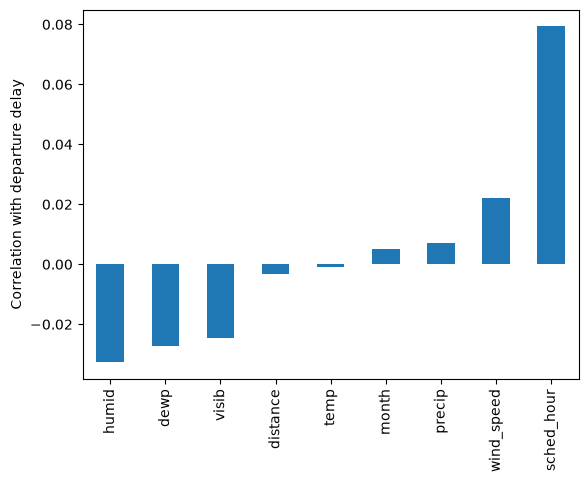

humid        -0.033
dewp         -0.027
visib        -0.025
distance     -0.003
temp         -0.001
month         0.005
precip        0.007
wind_speed    0.022
sched_hour    0.079
Name: dep_delay, dtype: float64

In [41]:
# ===== 41st code block (of 56) =====
# Chart 7: correlation of each number with departure delay (Session 3)
cols = ['dep_delay', 'sched_hour', 'month', 'distance', 'temp', 'dewp', 'humid', 'wind_speed', 'precip', 'visib']

corr_delay = df_clean[cols].corr()['dep_delay'].drop('dep_delay').sort_values()
corr_delay.plot(kind='bar')
plt.ylabel('Correlation with departure delay')
plt.show()

corr_delay.round(3)

**What the charts show:**
- **Risk builds through the day**, from 4% at 6am to 22% at 4pm, as morning delays carry through to later flights. The box plots show afternoon delays are not only more frequent but longer.
- **Season matters** (line chart): December, February and June–July are worst; spring and autumn calmest.
- **Carrier gaps are large and real:** Southwest (27%) is delayed more than twice as often as Alaska (10%).
- **Seattle and Portland follow the same pattern**, so one plan fits both.
- **Weather matters only at extremes:** freezing temperatures and poor visibility raise delays (tested in section 6). The scatter matrix shows no clear line between any weather measure and delay, and every correlation is below 0.1.

## 6. How sure are we?
Our numbers come from one year of flights, a sample. The histogram shows how much the delay rate moves between random samples of 1,000 flights; with 160,000 flights our estimates are far more precise.

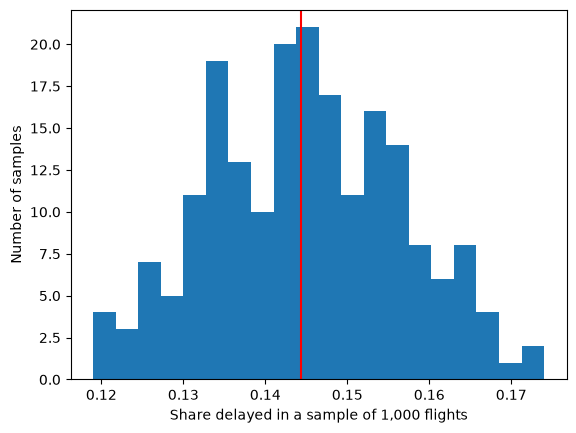

In [42]:
# ===== 42nd code block (of 56) =====
# How precise is our overall number? Take many random samples of 1,000 flights (Session 4)
sample_means = [df_clean['delayed'].sample(1000, random_state=i).mean() for i in range(200)]

plt.hist(sample_means, bins=20)
plt.axvline(pct_delayed, color='red')   # the share delayed across all flights
plt.xlabel('Share delayed in a sample of 1,000 flights')
plt.ylabel('Number of samples')
plt.show()

In [43]:
# ===== 43rd code block (of 56) =====
# 95% confidence interval for the overall share delayed (all flights)
sem = df_clean['delayed'].sem()
print('Share delayed:', round(pct_delayed * 100, 2), '%')
print('95% CI:', round((pct_delayed - 1.96 * sem) * 100, 2), '% to', round((pct_delayed + 1.96 * sem) * 100, 2), '%')

Share delayed: 14.44 %
95% CI: 14.27 % to 14.61 %


In [44]:
# ===== 44th code block (of 56) =====
# Confidence intervals by time of day
tod = df_clean.groupby('time_of_day', observed=True)['delayed'].agg(['mean', 'sem', 'size'])
tod['LOWER'] = tod['mean'] - 1.96 * tod['sem']
tod['UPPER'] = tod['mean'] + 1.96 * tod['sem']
tod.round(3)

,mean,sem,size,LOWER,UPPER
time_of_day,,,,,
night 0-4,0.103,0.010,904,0.083,0.123
morning 5-9,0.072,0.001,51867,0.069,0.074
midday 10-13,0.163,0.002,43743,0.159,0.166
afternoon 14-16,0.206,0.003,22103,0.201,0.211
evening 17-20,0.197,0.002,28747,0.193,0.202
late 21-23,0.155,0.003,12916,0.149,0.162


- **Overall delay rate:** 14.4% (95% interval 14.3%–14.6%).
- **Every time-of-day interval is narrow and none overlap** between morning and afternoon.

### Is the difference real? Hypothesis tests
**Null hypothesis:** the two groups have the same average delay, and any gap is luck. A small p-value (below 0.05) means our data would be very surprising if that were true.

In [45]:
# ===== 45th code block (of 56) =====
# Test 1: evening vs morning departures (delay in minutes)
evening = df_clean[df_clean['time_of_day'] == 'evening 17-20']['dep_delay']
morning = df_clean[df_clean['time_of_day'] == 'morning 5-9']['dep_delay']

print('Evening:', len(evening), 'flights, average delay', round(evening.mean(), 2), 'min')
print('Morning:', len(morning), 'flights, average delay', round(morning.mean(), 2), 'min')
print(stats.ttest_ind(evening, morning, equal_var=False))

# 95% confidence interval for the DIFFERENCE (Session 5)
difference = evening.mean() - morning.mean()
se_difference = np.sqrt(evening.sem() ** 2 + morning.sem() ** 2)
print('Difference:', round(difference, 2), 'min')
print('95% interval:', round(difference - 1.96 * se_difference, 2), 'to', round(difference + 1.96 * se_difference, 2))

Evening: 28747 flights, average delay 8.84 min
Morning: 51867 flights, average delay 2.19 min
TtestResult(statistic=np.float64(30.67274923840253), pvalue=np.float64(6.428305190487027e-205), df=np.float64(56383.73554132576))
Difference: 6.65 min
95% interval: 6.22 to 7.07


In [46]:
# ===== 46th code block (of 56) =====
# The same test for each weather condition, in one table
df_clean['freezing'] = np.where(df_clean['temp'] < 32, 'yes', 'no')
df_clean['low_visib'] = np.where(df_clean['visib'] < 3, 'yes', 'no')
df_clean['strong_wind'] = np.where(df_clean['wind_speed'] >= 20, 'yes', 'no')
df_clean['rain'] = np.where(df_clean['precip'] > 0, 'yes', 'no')

tests = []
for col in ['freezing', 'low_visib', 'strong_wind', 'rain']:
    yes = df_clean[df_clean[col] == 'yes']['dep_delay']
    no = df_clean[df_clean[col] == 'no']['dep_delay']
    diff = yes.mean() - no.mean()
    se = np.sqrt(yes.sem() ** 2 + no.sem() ** 2)
    tests.append({'Condition': col, 'Flights': len(yes),
                  'Avg delay (yes)': round(yes.mean(), 1), 'Avg delay (no)': round(no.mean(), 1),
                  'Difference (min)': round(diff, 1),
                  'LOWER': round(diff - 1.96 * se, 1), 'UPPER': round(diff + 1.96 * se, 1),
                  'p-value': stats.ttest_ind(yes, no, equal_var=False).pvalue})
pd.DataFrame(tests)

,Condition,Flights,Avg delay (yes),Avg delay (no),Difference (min),LOWER,UPPER,p-value
0,freezing,3542,11.8,6.0,5.8,4.7,7.0,7.000744e-24
1,low_visib,7961,8.4,6.0,2.4,1.7,3.0,1.095310e-11
2,strong_wind,3002,8.4,6.1,2.3,1.1,3.5,2.345238e-04
3,rain,16536,6.3,6.1,0.2,-0.3,0.6,4.967676e-01


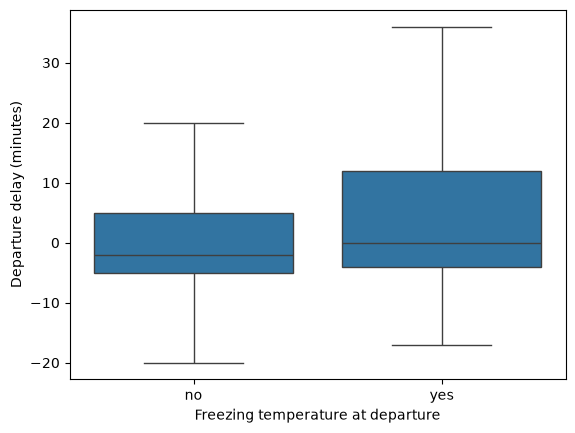

In [47]:
# ===== 47th code block (of 56) =====
# Box plot of the comparison (Session 5)
sns.boxplot(x='freezing', y='dep_delay', data=df_clean, showfliers=False)
plt.xlabel('Freezing temperature at departure')
plt.ylabel('Departure delay (minutes)')
plt.show()

**Results:**
- **Evening vs morning:** 8.8 vs 2.2 minutes, a gap of **6.7 minutes** (6.2–7.1), p < 0.001. Real.
- **Freezing temperatures:** +5.8 minutes (4.7–7.0). **Low visibility:** +2.4. **Strong wind:** +2.3. All real.
- **Rain:** +0.2 minutes, p = 0.50. **No evidence of a difference.**

**Significant is not the same as important.** With 160,000 flights, even tiny gaps test as "real". Seattle vs Portland differs by under one point, which matters little; the 6.7-minute evening gap clearly matters.

## 7. Predicting delay with regression
**Variables:** only information known *before* departure: scheduled hour, month, carrier, airport and weather. Arrival delay and actual departure time were excluded because they give away the answer.

We start with one predictor, as in a simple regression line.

In [48]:
# ===== 48th code block (of 56) =====
# Simple regression (Session 6): one predictor - scheduled departure hour
X = df_clean[['sched_hour']]      # double brackets: sklearn wants a table
y = df_clean['dep_delay']         # single brackets: the thing we are predicting

model = LinearRegression()        # create
model.fit(X, y)                   # fit

print('Slope    :', round(model.coef_[0], 3), 'minutes per hour later in the day')
print('Intercept:', round(model.intercept_, 2))
print('R squared:', round(model.score(X, y), 4))

Slope    : 0.452 minutes per hour later in the day
Intercept: 0.46
R squared: 0.0063


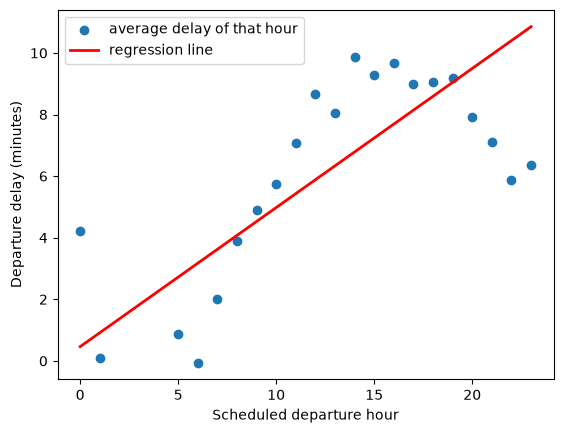

In [49]:
# ===== 49th code block (of 56) =====
# Visualize the regression line
# Points = average delay of each scheduled hour (individual flights are too many to see)
hour_avg = df_clean.groupby('sched_hour')['dep_delay'].mean()
plt.scatter(hour_avg.index, hour_avg.values, label='average delay of that hour')
plt.plot(hour_avg.index, model.predict(pd.DataFrame({'sched_hour': hour_avg.index})), color='red', linewidth=2, label='regression line')
plt.xlabel('Scheduled departure hour')
plt.ylabel('Departure delay (minutes)')
plt.legend()
plt.show()

- **Each hour later in the day adds about 0.45 minutes** of delay, but the line explains under 1% of the variation (R² = 0.006).
- The dots curve: delay rises until 4pm, then falls. A straight line cannot follow that shape, so we treat each hour as its own category in the next model.

In [50]:
# ===== 50th code block (of 56) =====
# Multiple regression: hour, month, carrier, airport and weather
# get_dummies turns categories (carrier = AS, WN ...) into 0/1 columns the model can use
predictors = ['sched_hour', 'month', 'carrier', 'origin', 'temp', 'humid', 'wind_speed', 'precip', 'visib']
model_data = df_clean[predictors + ['dep_delay']].dropna()
X_all = pd.get_dummies(model_data[predictors], columns=['sched_hour', 'month', 'carrier', 'origin'], drop_first=True)
y_all = model_data['dep_delay']

# Split: 80% to fit the model, 20% held back to test it on flights it has not seen
X_train = X_all.sample(frac=0.8, random_state=1)
X_test = X_all.drop(X_train.index)
y_train = y_all[X_train.index]
y_test = y_all[X_test.index]
print('Train:', len(X_train), ' Test:', len(X_test))

Train: 128166  Test: 32042


In [51]:
# ===== 51st code block (of 56) =====
# Compare models with and without weather (Session 6: "adding a predictor")
weather_cols_model = ['temp', 'humid', 'wind_speed', 'precip', 'visib']
schedule_cols = [c for c in X_all.columns if c not in weather_cols_model]

results = []
for name, cols_used in [('1. Weather only', weather_cols_model),
                        ('2. Schedule + airline', schedule_cols),
                        ('3. Both', list(X_all.columns))]:
    m = LinearRegression()
    m.fit(X_train[cols_used], y_train)
    mae = (y_test - m.predict(X_test[cols_used])).abs().mean()
    results.append({'Model': name, 'R squared (test)': round(m.score(X_test[cols_used], y_test), 3),
                    'Test MAE (minutes)': round(mae, 2)})

baseline_mae = (y_test - y_train.mean()).abs().mean()
results.append({'Model': 'Baseline (average)', 'R squared (test)': 0, 'Test MAE (minutes)': round(baseline_mae, 2)})
pd.DataFrame(results)

,Model,R squared (test),Test MAE (minutes)
0,1. Weather only,0.002,14.34
1,2. Schedule + airline,0.038,13.61
2,3. Both,0.040,13.63
3,Baseline (average),0.000,14.36


**Adding predictors, tested on 20% of flights held back:**
- **Weather alone** barely beats the baseline (14.34 vs 14.36 minutes).
- **Schedule and airline** cut the error to 13.61 minutes (R² = 0.04).
- **Adding weather** does not improve it, so **schedule + airline is our chosen model**, about 5% better than the baseline.

In [52]:
# ===== 52nd code block (of 56) =====
# Chosen model: schedule + airline (adding weather did not improve the test error)
model_2 = LinearRegression()
model_2.fit(X_train[schedule_cols], y_train)

# Coefficients: extra minutes of delay compared with the reference group (carrier AA, airport PDX)
coefs = pd.Series(model_2.coef_, index=schedule_cols)
coefs[coefs.index.str.startswith('carrier') | coefs.index.str.startswith('origin')].sort_values().round(2)

carrier_AS   -9.11
carrier_HA   -9.02
carrier_US   -8.04
carrier_OO   -7.54
carrier_DL   -6.06
carrier_VX   -3.79
carrier_B6   -3.26
carrier_UA   -0.46
carrier_F9   -0.12
origin_SEA    1.64
carrier_WN    2.16
dtype: float64

In [53]:
# ===== 53rd code block (of 56) =====
# Predict delays for flights of our choosing (Session 6)
new_flights = pd.DataFrame(0, index=['Alaska, 6am, April, SEA', 'Southwest, 4pm, December, SEA'], columns=schedule_cols)
new_flights.loc['Alaska, 6am, April, SEA', ['sched_hour_6.0', 'month_4', 'carrier_AS', 'origin_SEA']] = 1
new_flights.loc['Southwest, 4pm, December, SEA', ['sched_hour_16.0', 'month_12', 'carrier_WN', 'origin_SEA']] = 1
pd.Series(model_2.predict(new_flights), index=new_flights.index).round(1)

Alaska, 6am, April, SEA          -6.7
Southwest, 4pm, December, SEA    22.3
dtype: float64

**What the model says:** Alaska averages about 9 minutes less delay than American, Southwest 2 minutes more. An Alaska flight at 6am in April is predicted to leave about 7 minutes early; a Southwest flight at 4pm in December, 22 minutes late.

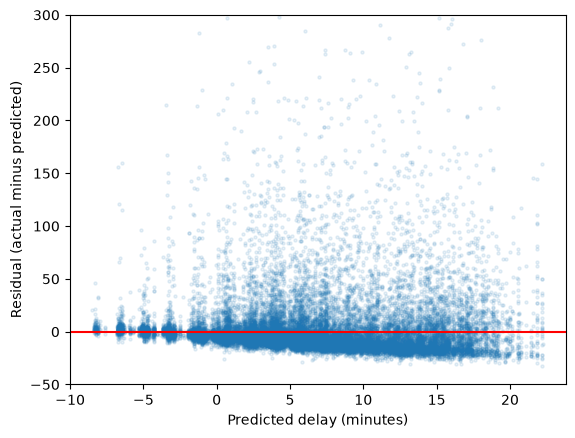

In [54]:
# ===== 54th code block (of 56) =====
# Where is the model wrong? Residual plot (Session 6)
pred_test = model_2.predict(X_test[schedule_cols])
residuals = y_test - pred_test

plt.scatter(pred_test, residuals, alpha=0.1, s=5)
plt.axhline(0, color='red')
plt.ylim(-50, 300)
plt.xlabel('Predicted delay (minutes)')
plt.ylabel('Residual (actual minus predicted)')
plt.show()

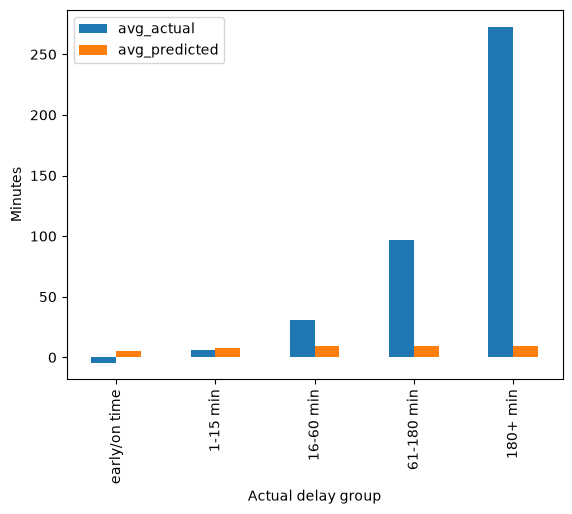

,flights,avg_actual,avg_predicted,avg_error
delay_group,,,,
early/on time,20743,-4.3,4.9,9.4
1-15 min,6616,6.0,7.6,5.4
16-60 min,3466,30.9,9.6,21.3
61-180 min,1081,96.9,9.2,87.7
180+ min,136,272.8,9.2,263.6


In [55]:
# ===== 55th code block (of 56) =====
# Error for different sizes of delay
fails = pd.DataFrame({'actual': y_test, 'predicted': pred_test, 'error': residuals.abs()})
fails['delay_group'] = pd.cut(fails['actual'], bins=[-100, 0, 15, 60, 180, 2000],
                              labels=['early/on time', '1-15 min', '16-60 min', '61-180 min', '180+ min'])
fails_table = fails.groupby('delay_group', observed=True).agg(flights=('error', 'size'),
                                                              avg_actual=('actual', 'mean'),
                                                              avg_predicted=('predicted', 'mean'),
                                                              avg_error=('error', 'mean'))
fails_table[['avg_actual', 'avg_predicted']].plot(kind='bar')
plt.xlabel('Actual delay group')
plt.ylabel('Minutes')
plt.show()

fails_table.round(1)

**Where it fails:** the residual plot is not a formless cloud; it has a long upward tail. The model predicts 5–10 minutes for almost every flight, so for flights 1–3 hours late it is off by 88 minutes. Those delays come from causes missing from our data, such as mechanical faults, crews and air-traffic holds.

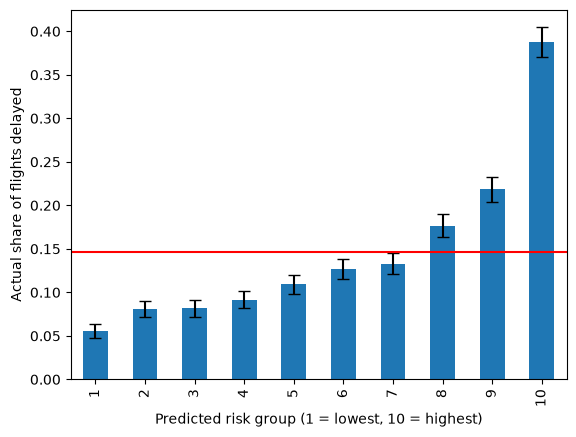

,mean,sem,size
risk_group,,,
1,0.056,0.004,3210
2,0.081,0.005,3217
3,0.081,0.005,3191
4,0.092,0.005,3200
5,0.109,0.006,3217
6,0.127,0.006,3208
7,0.133,0.006,3217
8,0.177,0.007,3174
9,0.218,0.007,3209


In [56]:
# ===== 56th code block (of 56) =====
# Even if minutes are hard to predict, can the model RANK flights by risk?
# Split test flights into 10 equal groups by predicted delay, and check the real share delayed
fails['delayed'] = (fails['actual'] > 15).astype(int)
fails['risk_group'] = pd.qcut(fails['predicted'], 10, labels=range(1, 11))
risk = fails.groupby('risk_group', observed=True)['delayed'].agg(['mean', 'sem', 'size'])

risk['mean'].plot(kind='bar', yerr=1.96 * risk['sem'], capsize=4)
plt.axhline(fails['delayed'].mean(), color='red')
plt.xlabel('Predicted risk group (1 = lowest, 10 = highest)')
plt.ylabel('Actual share of flights delayed')
plt.show()

risk.round(3)

**But it ranks flights by risk well:** its highest-risk tenth of flights was delayed 39% of the time, the lowest-risk tenth only 6%. That makes it useful for flagging which flights to watch.

## 8. Recommendation
**What to do:**
1. **Buffer the afternoon.** Put standby crews, spare gates and extra turnaround time on departures scheduled **between 2pm and 8pm**, delayed 20% of the time against 7% early in the morning.
2. **Plan ahead for December and freezing days**, using the freeze forecast to set staffing a day ahead.
3. **Work with high-delay carriers** (Southwest, Frontier, United, JetBlue, American) on afternoon turnaround times.
4. **Use the model to rank each day's flights by risk**, not to forecast exact minutes.

**How confident we are:**
- **High** that time of day, season and carrier drive delay risk: the effects are large and the intervals narrow.
- **Lower** on the size of weather effects, because extreme-weather hours are rare.

**What this analysis does not establish:**
- **Cause and effect.** The afternoon pattern may come from delays carried over from earlier flights.
- **Long delays and cancellations**, whose causes are not in our data.
- **Other years and airports.** The data covers only 2014 at two airports.
- **Weather at the destination**, which we did not include.

## Division of work
*(Replace with your team's actual contributions.)*
- **[Member 1]:** Combined the two datasets (in Excel with VLOOKUP and in Python), and investigated the unmatched flights.
- **[Member 2]:** Led the data cleaning, found the actual-vs-scheduled hour problem, and wrote the cleaning log.
- **[Member 3]:** Built the visualizations, confidence intervals and hypothesis tests.
- **[Member 4]:** Built and tested the regression models and drafted the recommendation.

**AI use statement (Hult AI policy):** *[State how AI tools were used, per your course's policy.]*